# 04a: Baseline Models

## Objective
Train a Seasonal Naive baseline forecasting model to establish performance benchmarks for weekly bed occupancy forecasting.

## Data Source
- **Hospital:** ADVENTHEALTH ORLANDO  
- **Date Range:** 2020-07-19 to 2024-04-21 (197 weeks)
- **Target Variable:** `bed_occupancy` (weekly average occupied beds)
- **Train/Test Split:** 157/40 weeks (80/20)

## Model
- **Seasonal Naive (52-week):** Uses the value from 52 weeks ago as the forecast


## Computational Notes

**Baseline models are simple calculations - no GPU required.**

### Seasonal Naive Method:
- Uses the value from **52 weeks ago** (same week last year)
- Captures annual seasonality in hospital occupancy
- Provides a benchmark for advanced models to beat

### Runtime:
- Training: <1 second
- This notebook completes in under 30 seconds total


## Install Dependencies (if needed)

If packages are missing, install them here.


In [ ]:
# ============================================================================
# PROJECT CONFIGURATION
# ============================================================================
import os

# Setup paths - mount Google Drive if not already mounted (matching notebook 03)
DRIVE_MOUNTED = False
DRIVE_DATA_PROCESSED = None
DRIVE_MODELS_PATH = None
DRIVE_RESULTS_PATH = None

try:
    from google.colab import drive
    # Check if drive is already mounted
    if os.path.exists('/content/drive'):
        DRIVE_MOUNTED = True
        print("✓ Google Drive already mounted")
    else:
        # Mount Google Drive
        print("📁 Mounting Google Drive...")
        drive.mount('/content/drive')
        DRIVE_MOUNTED = True
        print("✓ Google Drive mounted successfully")

    # Set up Google Drive paths
    if DRIVE_MOUNTED:
        DRIVE_ROOT = '/content/drive/MyDrive/hospital_occupancy_forecasting'
        DRIVE_DATA_PROCESSED = os.path.join(DRIVE_ROOT, 'data', 'processed')
        DRIVE_MODELS_PATH = os.path.join(DRIVE_ROOT, 'models')
        DRIVE_RESULTS_PATH = os.path.join(DRIVE_ROOT, 'results', 'visualizations', 'model_development')
        os.makedirs(DRIVE_DATA_PROCESSED, exist_ok=True)
        os.makedirs(DRIVE_MODELS_PATH, exist_ok=True)
        os.makedirs(DRIVE_RESULTS_PATH, exist_ok=True)
        print(f"✓ Google Drive paths configured: {DRIVE_ROOT}")
except ImportError:
    print("ℹ️  Not running in Google Colab (will only check local paths)")
except Exception as e:
    print(f"⚠️  Could not mount Google Drive: {e}")
    print("   Will continue with local Colab paths only")

# Local Colab paths
PROJECT_ROOT = '/content/hospital_occupancy_forecasting'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
DATA_RAW = os.path.join(DATA_DIR, 'raw')
DATA_PROCESSED = os.path.join(DATA_DIR, 'processed')
MODELS_PATH = os.path.join(PROJECT_ROOT, 'models')
RESULTS_PATH = os.path.join(PROJECT_ROOT, 'results', 'visualizations', 'model_development')

for path in [DATA_RAW, DATA_PROCESSED, MODELS_PATH, RESULTS_PATH]:
    os.makedirs(path, exist_ok=True)

# Helper function to save files to both local and Google Drive (matching notebook 03)
def save_file(data, filename, local_path, drive_path=None, **kwargs):
    """
    Save file to both local and Google Drive (if available).

    Args:
        data: Data to save (DataFrame, dict, model, etc.)
        filename: Name of the file
        local_path: Local directory path
        drive_path: Google Drive directory path (optional)
        **kwargs: Additional arguments for save methods (e.g., index=False for to_csv)
    """
    # Save to local
    local_file = os.path.join(local_path, filename)
    if isinstance(data, pd.DataFrame):
        data.to_csv(local_file, **kwargs)
    elif isinstance(data, (dict, list)) and filename.endswith('.json'):
        import json
        with open(local_file, 'w') as f:
            json.dump(data, f, **kwargs)
    elif filename.endswith('.pkl'):
        import pickle
        with open(local_file, 'wb') as f:
            pickle.dump(data, f)
    elif hasattr(data, 'save'):
        data.save(local_file)
    else:
        # Fallback: try to write as text
        with open(local_file, 'w') as f:
            f.write(str(data))
    print(f"✓ Saved to local: {local_file}")

    # Save to Google Drive if available
    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            if isinstance(data, pd.DataFrame):
                data.to_csv(drive_file, **kwargs)
            elif isinstance(data, (dict, list)) and filename.endswith('.json'):
                import json
                with open(drive_file, 'w') as f:
                    json.dump(data, f, **kwargs)
            elif filename.endswith('.pkl'):
                import pickle
                with open(drive_file, 'wb') as f:
                    pickle.dump(data, f)
            elif hasattr(data, 'save'):
                data.save(drive_file)
            else:
                with open(drive_file, 'w') as f:
                    f.write(str(data))
            print(f"✓ Saved to Google Drive: {drive_file}")
        except Exception as e:
            print(f"⚠️  Could not save to Google Drive: {e}")

# Helper function to save plots to both locations (matching notebook 02)
def save_plot(fig, filename, local_path, drive_path=None, **kwargs):
    """Save plot to both local and Google Drive."""
    local_file = os.path.join(local_path, filename)
    fig.savefig(local_file, **kwargs)
    print(f"✓ Saved plot to local: {local_file}")

    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            fig.savefig(drive_file, **kwargs)
            print(f"✓ Saved plot to Google Drive: {drive_file}")
        except Exception as e:
            print(f"⚠️  Could not save plot to Google Drive: {e}")

# Helper function to load file from multiple locations (matching notebook 03)
def load_file(filename, local_path, drive_path=None):
    """
    Load file from local or Google Drive (local priority).

    Returns:
        Loaded data or None if not found
    """
    # Try local first
    local_file = os.path.join(local_path, filename)
    if os.path.exists(local_file):
        if filename.endswith('.csv'):
            return pd.read_csv(local_file, index_col=0, parse_dates=True)
        elif filename.endswith('.pkl'):
            import pickle
            with open(local_file, 'rb') as f:
                return pickle.load(f)
        elif filename.endswith('.json'):
            import json
            with open(local_file, 'r') as f:
                return json.load(f)
        elif filename.endswith('.h5'):
            from tensorflow import keras
            return keras.models.load_model(local_file)

    # Try Google Drive if available
    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            if os.path.exists(drive_file):
                if filename.endswith('.csv'):
                    return pd.read_csv(drive_file, index_col=0, parse_dates=True)
                elif filename.endswith('.pkl'):
                    import pickle
                    with open(drive_file, 'rb') as f:
                        return pickle.load(f)
                elif filename.endswith('.json'):
                    import json
                    with open(drive_file, 'r') as f:
                        return json.load(f)
                elif filename.endswith('.h5'):
                    from tensorflow import keras
                    return keras.models.load_model(drive_file)
        except Exception as e:
            print(f"⚠️  Could not load from Google Drive: {e}")

    return None



📁 Mounting Google Drive...
Mounted at /content/drive
✓ Google Drive mounted successfully
✓ Google Drive paths configured: /content/drive/MyDrive/hospital_occupancy_forecasting


In [ ]:
try:
    import pmdarima
    print("✓ pmdarima is already installed")
except ImportError:
    print("Installing pmdarima...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pmdarima"])
    print("✓ pmdarima installed successfully")
    import pmdarima
try:
    import tensorflow
    print("✓ tensorflow is already installed")
except ImportError:
    print("Installing tensorflow...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow"])
    print("✓ tensorflow installed successfully")

Installing pmdarima...
✓ pmdarima installed successfully
✓ tensorflow is already installed


## Baseline Forecasting for Weekly Bed Occupancy

This notebook establishes baseline performance benchmarks using a simple forecasting method:
- **Seasonal Naive:** Value from 52 weeks ago (annual seasonality)  

This baseline provides a reference point for evaluating more sophisticated models (ARIMAX, LSTM, VAR).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import random
warnings.filterwarnings('ignore')

# External time-series CV splitter
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Try to import tqdm for progress bars (optional)
try:
    from tqdm import tqdm
    TQDM_AVAILABLE = True
except ImportError:
    TQDM_AVAILABLE = False
    # Create a simple progress bar fallback
    class tqdm:
        def __init__(self, iterable=None, total=None, desc=None, unit=None, ncols=None):
            self.iterable = iterable
            self.total = total or (len(iterable) if iterable else None)
            self.desc = desc or ""
            self.unit = unit or "it"
            self.current = 0
            self.last_print = 0

        def __enter__(self):
            if self.desc:
                print(f"{self.desc}...", end="", flush=True)
            return self

        def __exit__(self, *args):
            print()  # New line after completion

        def __iter__(self):
            if self.iterable is None:
                return self
            for item in self.iterable:
                yield item
                self.update(1)

        def update(self, n=1):
            self.current += n
            if self.total:
                pct = (self.current / self.total) * 100
                # Print every 10% or every 100 items
                if pct - self.last_print >= 10 or (self.current % 100 == 0 and self.current > 0):
                    print(f"\r{self.desc}: {self.current}/{self.total} ({pct:.1f}%)", end="", flush=True)
                    self.last_print = pct
                if self.current >= self.total:
                    print()  # New line when complete
            else:
                if self.current % 100 == 0:
                    print(f"\r{self.desc}: {self.current} {self.unit}", end="", flush=True)

        def set_description(self, desc):
            self.desc = desc

# Set random seed for reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ============================================================================
# PERFORMANCE OPTIMIZATION CONFIGURATION
# ============================================================================
# Optimized for Google Colab T4 GPU - faster training with minimal accuracy loss

# Configuration
TRAIN_TEST_SPLIT = 0.8

# ARIMA/SARIMA configuration - OPTIMIZED for speed and accuracy
ARIMA_MAX_P = 5  # Increased to allow more AR terms (was 3, now 5 for better pattern capture)
ARIMA_MAX_Q = 5  # Increased to allow more MA terms (was 3, now 5 for better pattern capture)
ARIMA_N_JOBS = -1  # Use all CPU cores
ARIMA_USE_APPROXIMATION = True  # Faster but less precise
ARIMA_MAX_ORDER = 12  # Increased to allow more complex models (was 8, now 12)
ARIMA_MAX_ITER = 15  # Slightly increased iterations for better convergence (was 10)

SARIMA_MAX_P = 2
SARIMA_MAX_Q = 2
SARIMA_MAX_P_SEASONAL = 1
SARIMA_MAX_Q_SEASONAL = 1
SARIMA_MAX_ORDER = 6
SARIMA_N_JOBS = -1
SARIMA_USE_APPROXIMATION = True  # Faster search
SARIMA_MAX_ITER = 10  # Limit iterations for speed

# ============================================================================
# WEEKLY DATA CONFIGURATION (from 03_feature_engineering.ipynb)
# ============================================================================
# Data is weekly bed occupancy (145 weeks after lag_52 dropna)
DATA_FREQUENCY = 'weekly'
WEEKS_PER_YEAR = 52
FORECAST_HORIZON = 4  # Forecast 4 weeks ahead

# Baseline model configuration for weekly data
SEASONAL_PERIOD = 52  # Annual seasonality (52 weeks)

# VAR configuration (for informational purposes - not used in baseline models)
VAR_MAX_LAGS = 4  # Maximum lags to consider (4 weeks = 1 month)
VAR_IC = 'aic'  # Use AIC for lag selection
VAR_SKIP_GRANGER = True  # Skip Granger causality tests (faster)

# ARIMAX configuration (for informational purposes - not used in baseline models)
ARIMAX_RETRAIN_FREQUENCY = 30  # Retrain frequency in days

# LSTM configuration - OPTIMIZED for weekly data
LSTM_ARCHITECTURE_SEARCH = False  # Skip architecture search (use standard)
LSTM_BATCH_SIZE_SEARCH = False  # Skip batch size search (use 32)
LSTM_BATCH_SIZE = 16  # Smaller batch for weekly data (fewer samples)
LSTM_MAX_EPOCHS = 50  # More epochs for weekly data
LSTM_EARLY_STOPPING_PATIENCE = 10  # More patience for weekly data
LSTM_SEQUENCE_LENGTH = 12  # 12 weeks lookback (3 months)
LSTM_VALIDATION_SPLIT = 0.2


# Import ARIMA/SARIMA
from statsmodels.tsa.arima.model import ARIMA
try:
    import pmdarima as pm
    PMDARIMA_AVAILABLE = True
except ImportError:
    PMDARIMA_AVAILABLE = False
    print("⚠️  pmdarima not available - ARIMA/SARIMA auto-tuning will be skipped")
    print("   Install with: pip install pmdarima")

# Import VAR
from statsmodels.tsa.api import VAR

# Import TensorFlow for LSTM
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
    from sklearn.preprocessing import MinMaxScaler
    TENSORFLOW_AVAILABLE = True
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f"🚀 GPU detected: {len(gpus)} GPU(s) available")
        print(f"   GPU: {gpus[0].name}")
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            tf.random.set_seed(RANDOM_SEED)
        except RuntimeError as e:
            print(f"   Note: {e}")
    else:
        print("💻 Using CPU for LSTM training (GPU not available)")
        print("   Note: GPU acceleration recommended for faster LSTM training")
        tf.random.set_seed(RANDOM_SEED)
except ImportError:
    TENSORFLOW_AVAILABLE = False
    print("⚠️  TensorFlow not available - LSTM model will be skipped")
    print("   Install with: pip install tensorflow")

# Baseline forecast functions
def seasonal_naive_forecast(train_data, horizon, season_length=52):
    """Seasonal naive forecast: use value from same week in previous year (52-week seasonality).

    Notes:
        - If there is less than one full season of history, this falls back to using
          the last observed value for all horizons.
    """
    if len(train_data) < season_length:
        # Fallback: repeat last observed value if not enough history for seasonality
        last_value = train_data.iloc[-1] if isinstance(train_data, pd.Series) else train_data[-1]
        return np.full(horizon, last_value)
    forecasts = []
    for i in range(horizon):
        idx = len(train_data) - season_length + (i % season_length)
        if isinstance(train_data, pd.Series):
            forecasts.append(train_data.iloc[idx])
        else:
            forecasts.append(train_data[idx])
    return np.array(forecasts)

## Load Data


In [ ]:
# Load weekly bed occupancy time series (from 03_feature_engineering.ipynb)
# Try local first, then Google Drive
data = load_file('occupancy_with_features.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)

if data is not None:
    if 'bed_occupancy' in data.columns:
        target_series = data['bed_occupancy']
    else:
        # Try alternative column names
        occupancy_cols = [c for c in data.columns if 'occupancy' in c.lower() or 'bed' in c.lower()]
        if occupancy_cols:
            target_series = data[occupancy_cols[0]]
            print(f"Using column: {occupancy_cols[0]}")
        else:
            target_series = data.iloc[:, 0]
            print(f"Using first column: {data.columns[0]}")
    print(f"Loaded weekly bed occupancy: {len(data)} weeks")
    print(f"Date range: {data.index.min()} to {data.index.max()}")
    print(f"\nTarget variable (bed_occupancy) statistics:")
    print(target_series.describe())
else:
    # Fallback: try loading from features_for_arimax.csv
    data = load_file('features_for_arimax.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)
    if data is not None:
        if 'bed_occupancy' in data.columns:
            target_series = data['bed_occupancy']
            print(f"Loaded data from ARIMAX features file: {len(data)} weeks")
            print(f"Date range: {data.index.min()} to {data.index.max()}")
            print(f"\nTarget variable (bed_occupancy) statistics:")
            print(target_series.describe())
        else:
            print(f"File found but 'bed_occupancy' column not found")
            print(f"Available columns: {list(data.columns[:10])}...")
            target_series = pd.Series(dtype=float)
            data = None
    else:
        print(f"File not found: occupancy_with_features.csv")
        print(f"Also tried: features_for_arimax.csv")
        print("\nPlease run notebooks 01-03 first to create weekly bed occupancy data.")
        target_series = pd.Series(dtype=float)
        data = None

Loaded weekly bed occupancy: 197 weeks
Date range: 2020-07-19 00:00:00 to 2024-04-21 00:00:00

Target variable (bed_occupancy) statistics:
count     197.000000
mean     2254.367005
std       136.466602
min      1882.000000
25%      2184.700000
50%      2269.400000
75%      2353.400000
max      2510.700000
Name: bed_occupancy, dtype: float64


## Train-Test Split


Train set: 157 weeks (2020-07-19 00:00:00 to 2023-07-16 00:00:00)
Test set: 40 weeks (2023-07-23 00:00:00 to 2024-04-21 00:00:00)
Train/Test split: 157/40 = 80.0%
✓ Saved plot to local: /content/hospital_occupancy_forecasting/results/visualizations/model_development/train_test_split.png
✓ Saved plot to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/results/visualizations/model_development/train_test_split.png


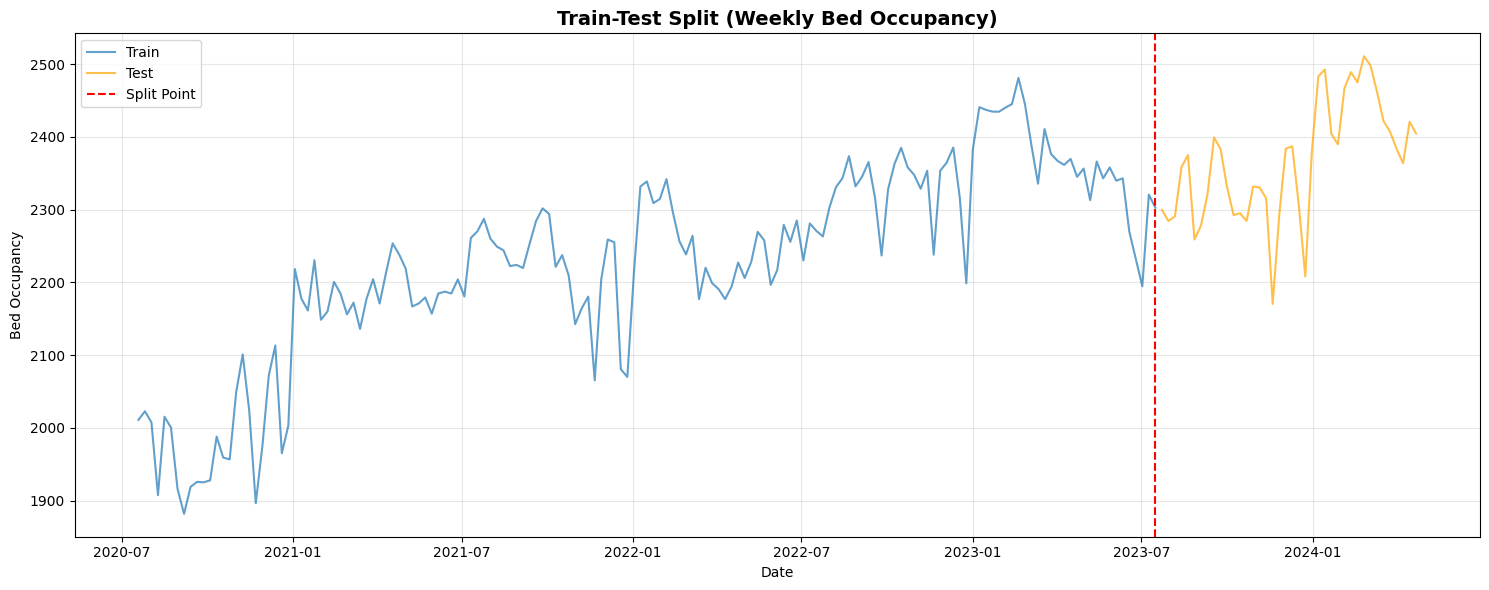

In [ ]:
if len(target_series) > 0:
    train_size = int(len(target_series) * TRAIN_TEST_SPLIT)
    train_data = target_series[:train_size]
    test_data = target_series[train_size:]
    print(f"Train set: {len(train_data)} weeks ({train_data.index.min()} to {train_data.index.max()})")
    print(f"Test set: {len(test_data)} weeks ({test_data.index.min()} to {test_data.index.max()})")
    print(f"Train/Test split: {len(train_data)}/{len(test_data)} = {TRAIN_TEST_SPLIT:.1%}")
    plt.figure(figsize=(15, 6))
    plt.plot(train_data.index, train_data.values, label='Train', alpha=0.7, linewidth=1.5)
    plt.plot(test_data.index, test_data.values, label='Test', alpha=0.7, linewidth=1.5, color='orange')
    plt.axvline(x=train_data.index[-1], color='red', linestyle='--', label='Split Point')
    plt.title('Train-Test Split (Weekly Bed Occupancy)', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Bed Occupancy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_plot(plt.gcf(), 'train_test_split.png', RESULTS_PATH, DRIVE_RESULTS_PATH, dpi=300, bbox_inches='tight')
    plt.show()
else:
    train_data = pd.Series(dtype=float)
    test_data = pd.Series(dtype=float)

## Baseline Models

We'll start with simple baseline models to establish a performance benchmark.


TRAINING BASELINE MODELS FOR WEEKLY BED OCCUPANCY

Forecast horizon: 40 weeks

Training Seasonal Naive Forecast (52-week seasonality)...

✓ Baseline models trained. Forecast horizon: 40 weeks
✓ Saved plot to local: /content/hospital_occupancy_forecasting/results/visualizations/model_development/baseline_forecasts.png
✓ Saved plot to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/results/visualizations/model_development/baseline_forecasts.png


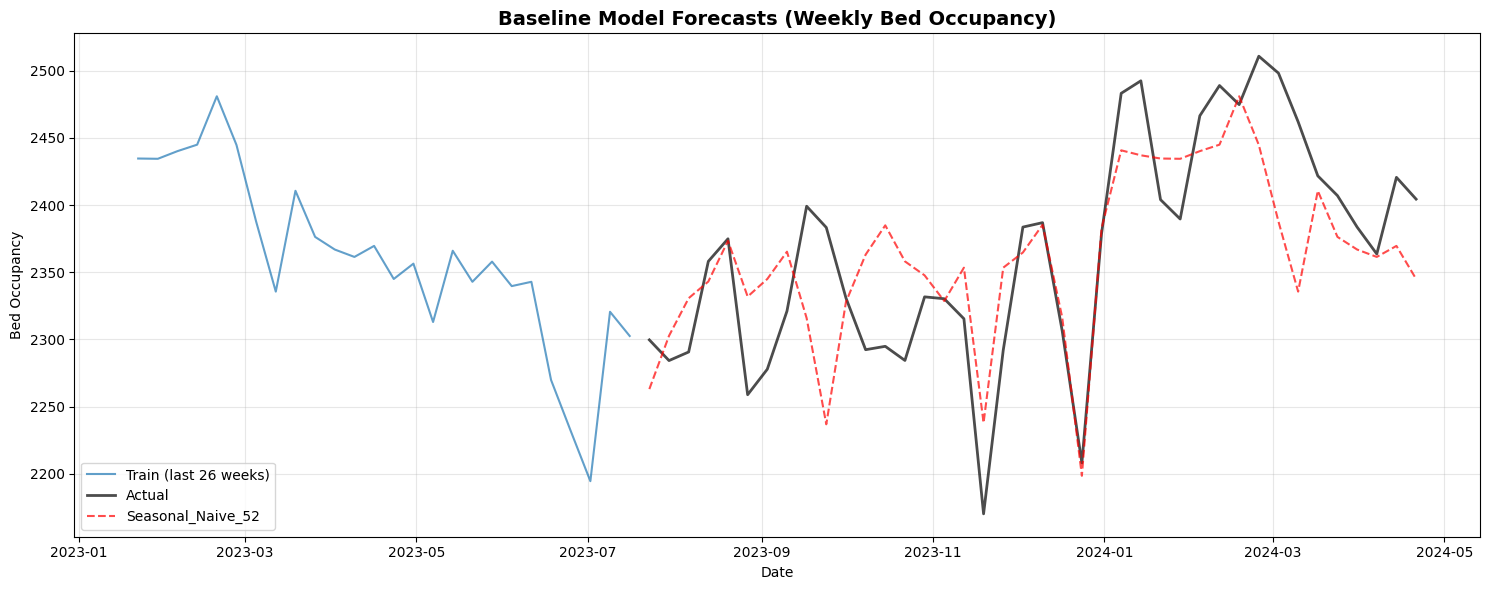

✓ Saved to local: /content/hospital_occupancy_forecasting/models/baseline_forecasts.csv
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/models/baseline_forecasts.csv


In [ ]:
baseline_forecasts = {}
if len(train_data) > 0 and len(test_data) > 0:
    horizon = len(test_data)
    print("="*70)
    print("TRAINING BASELINE MODELS FOR WEEKLY BED OCCUPANCY")
    print("="*70)
    print(f"\nForecast horizon: {horizon} weeks")
    print()

    print("Training Seasonal Naive Forecast (52-week seasonality)...")
    if len(train_data) >= SEASONAL_PERIOD:
        seasonal_naive_pred = seasonal_naive_forecast(train_data, horizon, season_length=SEASONAL_PERIOD)
        baseline_forecasts['Seasonal_Naive_52'] = pd.Series(seasonal_naive_pred, index=test_data.index)
    else:
        print(f"   Skipped: Insufficient data for 52-week seasonality (need {SEASONAL_PERIOD}, have {len(train_data)})")

    # Only Seasonal Naive baseline is kept for this notebook
    print(f"\n✓ Baseline models trained. Forecast horizon: {horizon} weeks")
    plt.figure(figsize=(15, 6))
    # Show last 26 weeks of training data (half year)
    train_display = min(26, len(train_data))
    plt.plot(train_data.index[-train_display:], train_data.values[-train_display:],
             label=f'Train (last {train_display} weeks)', alpha=0.7, linewidth=1.5)
    plt.plot(test_data.index, test_data.values, label='Actual', alpha=0.7, color='black', linewidth=2)
    colors = ['red', 'green', 'blue', 'purple']
    for i, (name, forecast) in enumerate(baseline_forecasts.items()):
        plt.plot(forecast.index, forecast.values, label=name, alpha=0.7, linestyle='--', color=colors[i % len(colors)])
    plt.title('Baseline Model Forecasts (Weekly Bed Occupancy)', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Bed Occupancy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_plot(plt.gcf(), 'baseline_forecasts.png', RESULTS_PATH, DRIVE_RESULTS_PATH, dpi=300, bbox_inches='tight')
    plt.show()

    # Save baseline forecasts for evaluation
    baseline_forecasts_df = pd.DataFrame(baseline_forecasts)
    save_file(baseline_forecasts_df, 'baseline_forecasts.csv', MODELS_PATH, DRIVE_MODELS_PATH)
else:
    print("Insufficient data for baseline models")

## Model Evaluation

Calculate basic evaluation metrics to assess model performance.


In [ ]:
# ============================================================================
# MODEL EVALUATION METRICS
# ============================================================================

if len(baseline_forecasts) > 0 and len(test_data) > 0:
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    from statsmodels.stats.diagnostic import acorr_ljungbox

    def calculate_mape(y_true, y_pred):
        """Calculate Mean Absolute Percentage Error."""
        mask = y_true != 0
        if mask.sum() == 0:
            return np.nan
        return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    def calculate_mase(y_true, y_pred, training_series, seasonality=SEASONAL_PERIOD):
        """Mean Absolute Scaled Error using seasonal naive baseline."""
        if training_series is None or len(training_series) <= seasonality:
            return np.nan
        train_values = np.asarray(training_series)
        diffs = np.abs(train_values[seasonality:] - train_values[:-seasonality])
        if len(diffs) == 0:
            return np.nan
        scale = np.mean(diffs)
        if scale == 0:
            return np.nan
        return np.mean(np.abs(y_true - y_pred)) / scale

    def compute_horizon_errors(y_true, y_pred, horizons=(1, 2, 4)):
        """Compute horizon-specific MAE and RMSE for select lead times."""
        horizon_metrics = {}
        for h in horizons:
            if len(y_true) >= h and len(y_pred) >= h:
                err = y_true[h - 1] - y_pred[h - 1]
                horizon_metrics[h] = {
                    "MAE": float(np.abs(err)),
                    "RMSE": float(np.sqrt(err**2))
                }
        return horizon_metrics

    print("="*70)
    print("BASELINE MODELS - EVALUATION METRICS (WEEKLY BED OCCUPANCY)")
    print("="*70)
    print(f"\nTest period: {len(test_data)} weeks")
    print(f"Date range: {test_data.index.min()} to {test_data.index.max()}\n")

    results = {}

    for model_name, forecast in baseline_forecasts.items():
        # Align forecast with test_data
        forecast_aligned = forecast.reindex(test_data.index)

        # Remove NaN values for metric calculation
        mask = ~(forecast_aligned.isna() | test_data.isna())
        if mask.sum() == 0:
            print(f"⚠️  {model_name}: No valid data for evaluation")
            continue

        y_true = test_data[mask].values
        y_pred = forecast_aligned[mask].values

        # Core accuracy metrics
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mape = calculate_mape(y_true, y_pred)
        mase = calculate_mase(y_true, y_pred, train_data.values if len(train_data) > 0 else None)

        # Bias (mean forecast error)
        bias = float(np.mean(y_pred - y_true))

        # Horizon-aware metrics (1, 2, 4-week ahead if available)
        horizon_metrics = compute_horizon_errors(y_true, y_pred)

        # Residual autocorrelation diagnostic (Ljung-Box p-value)
        lb_pvalue = np.nan
        try:
            if len(y_true) >= 10:
                lb_df = acorr_ljungbox(y_true - y_pred, lags=[min(10, len(y_true) // 2)], return_df=True)
                lb_pvalue = float(lb_df["lb_pvalue"].iloc[0])
        except Exception:
            lb_pvalue = np.nan

        results[model_name] = {
            "MAE": mae,
            "RMSE": rmse,
            "MAPE": mape,
            "MASE": mase,
            "Bias": bias,
            "Residual_AC_pvalue": lb_pvalue,
            "Horizon_1w_MAE": horizon_metrics.get(1, {}).get("MAE", np.nan),
            "Horizon_2w_MAE": horizon_metrics.get(2, {}).get("MAE", np.nan),
            "Horizon_4w_MAE": horizon_metrics.get(4, {}).get("MAE", np.nan),
            "Horizon_1w_RMSE": horizon_metrics.get(1, {}).get("RMSE", np.nan),
            "Horizon_2w_RMSE": horizon_metrics.get(2, {}).get("RMSE", np.nan),
            "Horizon_4w_RMSE": horizon_metrics.get(4, {}).get("RMSE", np.nan),
        }

    # Display results in a table
    if results:
        print(f"{'Model':<25} {'MAE':<10} {'RMSE':<10} {'MAPE (%)':<12} {'MASE':<10} {'Bias':<10}")
        print("-"*90)
        for model_name, metrics in results.items():
            mape_str = f"{metrics['MAPE']:.2f}" if not np.isnan(metrics["MAPE"]) else "N/A"
            mase_str = f"{metrics['MASE']:.2f}" if not np.isnan(metrics["MASE"]) else "N/A"
            print(f"{model_name:<25} {metrics['MAE']:<10.2f} {metrics['RMSE']:<10.2f} {mape_str:<12} {mase_str:<10} {metrics['Bias']:<10.2f}")

        # Horizon-aware metrics display
        print("\nHorizon-specific errors (absolute values):")
        print(f"{'Model':<25} {'1w MAE':<10} {'2w MAE':<10} {'4w MAE':<10} {'1w RMSE':<10} {'2w RMSE':<10} {'4w RMSE':<10}")
        print("-"*90)
        for model_name, metrics in results.items():
            def fmt(value):
                return f"{value:.2f}" if not np.isnan(value) else "N/A"
            print(
                f"{model_name:<25} "
                f"{fmt(metrics['Horizon_1w_MAE']):<10} "
                f"{fmt(metrics['Horizon_2w_MAE']):<10} "
                f"{fmt(metrics['Horizon_4w_MAE']):<10} "
                f"{fmt(metrics['Horizon_1w_RMSE']):<10} "
                f"{fmt(metrics['Horizon_2w_RMSE']):<10} "
                f"{fmt(metrics['Horizon_4w_RMSE']):<10}"
            )

        # Highlight best models (lower is better for error metrics)
        print("\n" + "="*70)
        print("BEST MODELS BY METRIC:")
        print("="*70)
        best_mae = min(results.items(), key=lambda x: x[1]["MAE"])
        best_rmse = min(results.items(), key=lambda x: x[1]["RMSE"])
        best_mape_candidates = [(k, v) for k, v in results.items() if not np.isnan(v["MAPE"])]
        best_mase_candidates = [(k, v) for k, v in results.items() if not np.isnan(v["MASE"])]
        best_mape = min(best_mape_candidates, key=lambda x: x[1]["MAPE"], default=(None, None))
        best_mase = min(best_mase_candidates, key=lambda x: x[1]["MASE"], default=(None, None))

        print(f"Best MAE:   {best_mae[0]} ({best_mae[1]['MAE']:.2f})")
        print(f"Best RMSE:  {best_rmse[0]} ({best_rmse[1]['RMSE']:.2f})")
        if best_mape[0]:
            print(f"Best MAPE:  {best_mape[0]} ({best_mape[1]['MAPE']:.2f}%)")
        if best_mase[0]:
            print(f"Best MASE:  {best_mase[0]} ({best_mase[1]['MASE']:.2f})")

        # Save results
        results_df = pd.DataFrame(results).T
        results_df = results_df[
            [
                "MAE", "RMSE", "MAPE", "MASE", "Bias", "Residual_AC_pvalue",
                "Horizon_1w_MAE", "Horizon_2w_MAE", "Horizon_4w_MAE",
                "Horizon_1w_RMSE", "Horizon_2w_RMSE", "Horizon_4w_RMSE"
            ]
        ]
        save_file(results_df, 'baseline_models_evaluation.csv', MODELS_PATH, DRIVE_MODELS_PATH)
        print(f"\n✓ Evaluation metrics saved to baseline_models_evaluation.csv")
    else:
        print("⚠️  No valid results to display")
else:
    print("⚠️  Cannot evaluate: No forecasts or test data available")




BASELINE MODELS - EVALUATION METRICS (WEEKLY BED OCCUPANCY)

Test period: 40 weeks
Date range: 2023-07-23 00:00:00 to 2024-04-21 00:00:00

Model                     MAE        RMSE       MAPE (%)     MASE       Bias      
------------------------------------------------------------------------------------------
Seasonal_Naive_52         42.88      55.51      1.81         0.32       -5.09     

Horizon-specific errors (absolute values):
Model                     1w MAE     2w MAE     4w MAE     1w RMSE    2w RMSE    4w RMSE   
------------------------------------------------------------------------------------------
Seasonal_Naive_52         36.60      18.40      15.00      36.60      18.40      15.00     

BEST MODELS BY METRIC:
Best MAE:   Seasonal_Naive_52 (42.88)
Best RMSE:  Seasonal_Naive_52 (55.51)
Best MAPE:  Seasonal_Naive_52 (1.81%)
Best MASE:  Seasonal_Naive_52 (0.32)
✓ Saved to local: /content/hospital_occupancy_forecasting/models/baseline_models_evaluation.csv
✓ Saved to Goo

## Summary

This notebook:
- ✅ Loaded weekly bed occupancy data and created a chronological train/test split.
- ✅ Trained a **Seasonal Naive** baseline model using a 52-week seasonal pattern.
- ✅ Evaluated the baseline over **40 test weeks** (2023-07-23 to 2024-04-21).
- ✅ Saved baseline forecasts and evaluation metrics to the `models` directory.

### Baseline Model Performance (Seasonal_Naive_52)

Key metrics reported for the baseline:
- Core accuracy: **MAE**, **RMSE**, **MAPE**
- Baseline-relative: **MASE** (vs seasonal naive)
- Diagnostics: **Bias** and residual Ljung-Box p-value
- Horizon-aware: 1, 2, and 4-week MAE/RMSE

### Interpretation

- The Seasonal Naive benchmark provides a seasonally-aware floor for accuracy.
- Advanced models (ARIMAX, VAR, LSTM) should beat the baseline on MAE/RMSE/MAPE and improve MASE (<1) on the same test period.